In [ ]:
#import all necessary packages
import os
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ttest_ind, mannwhitneyu
import seaborn as sns
from scipy.stats import kruskal

In [2]:
#import BL, 2CX and HD files
BL_dir = "/mnt/e/HL_Python/01_raw_output/BL/"
HD_dir = "/mnt/e/HL_Python/01_raw_output/HD_with_artifical_multianno_file/"
FU_dir = "/mnt/e/HL_Python/01_raw_output/FU_with_BL_multianno/"
EOT_dir = "/mnt/e/HL_Python/01_raw_output/FU_with_BL_multianno/"
output_folder = "/mnt/e/HL_Python/03_Analysis/combined_analysis/"

BL_files = glob.glob(os.path.join(BL_dir, "*consensus_aligned_zones.csv"))
HD_files = glob.glob(os.path.join(HD_dir, "*zones_100th.csv"))
FU_files = glob.glob(os.path.join(FU_dir, "*_2CX_cfDNA_consensus_aligned_zones.csv"))
EOT_files = glob.glob(os.path.join(EOT_dir, "*_EOT_cfDNA_consensus_aligned_zones.csv"))

In [ ]:
def process_files(file_list, sample_label, prefix_trim, output_folder):
    for file in file_list:
        # Generate the file prefix and define the output CSV path
        file_prefix = os.path.splitext(os.path.basename(file))[0][:-prefix_trim]
        csv_file_duplex_filtered = os.path.join(output_folder, f"{file_prefix}_duplex.csv")
        
        # List to hold filtered data chunks
        filtered_data_duplex_chunks = []
        
        # Read the file in chunks, filter, and add the sample label
        for chunk in pd.read_csv(file, chunksize=10000, low_memory=False):
            duplex_reads = chunk.loc[
                (chunk['XJ'] >= 1) & (chunk['XI'] >= 1),
                ["template_length", "start_motif", "end_motif", "XI", "XJ", "qnames", "chr", "reference_start", "reference_end"]]
            
            if not duplex_reads.empty:
                duplex_reads['sample'] = sample_label
                filtered_data_chunks.append(duplex_reads)
        
        # If there are any filtered chunks, concatenate and save
        if filtered_data_chunks:
            final_duplex_filtered_df = pd.concat(filtered_data_duplex_chunks, ignore_index=True)
            final_duplex_filtered_df.to_csv(csv_file_duplex_filtered, index=False)
        
        # Free memory by deleting variables
        del filtered_data_chunks, final_filtered_df

# Process each list with the appropriate prefix trimming and sample label
process_files(BL_files, "BL", 30, output_folder)
process_files(FU_files, "2CX", 30, output_folder)
process_files(HD_files, "HD", 24, output_folder)
process_files(EOT_files, "EOT", 30, output_folder)

calculate mean frequency of bases (A, T, G, C) over the first & last six positions of every read in every sample

In [7]:
data_directory = "/mnt/e/HL_Python/03_Analysis/combined_analysis/"
csv_file_base_frequency = "HD21_length_bins_base_distribution_20241018.csv"
bins = np.arange(0, 1010, 10)
labels = [f'{i}-{i+10}' for i in bins[:-1]]

# Change directory to where the files are located
os.chdir(data_directory)

# Load files with the appropriate naming patterns
BL_files_duplex = glob.glob("*_BL_duplex.csv")
FU_files_duplex = glob.glob("*_2CX_duplex.csv")
HD_files_duplex = glob.glob("*_HL_cfDNA_duplex.csv")
EOT_files_duplex = glob.glob("*_EOT_duplex.csv")

# Initialize an empty list to store DataFrames
all_dfs = []

# Function to calculate base percentages for A, T, G, C
def calculate_base_percentages(column):
    counts = column.str[:6].apply(list).explode().value_counts(normalize=True)
    return counts.get('A', 0), counts.get('T', 0), counts.get('G', 0), counts.get('C', 0)

# Generalized function to process files
def process_files(duplex_files, timepoint_label):
    for file in duplex_files:
        # Extract patient ID from the filename (adjust as per your naming convention)
        patient = os.path.splitext(os.path.basename(file))[0][:-10]
        
        # Read CSV file into a DataFrame and process data
        input_df = pd.read_csv(file)
        input_df["template_length"] = input_df["template_length"].abs()  # Absolute template length
        
        # Bin the template_length
        input_df['Binned_Template_Length'] = pd.cut(input_df['template_length'], bins=bins, labels=labels, right=False)

        # Calculate normalized counts of reads in each bin
        binned_counts_normalized = (
            input_df['Binned_Template_Length']
            .value_counts()
            .sort_index()
            .reindex(labels, fill_value=0) / input_df.shape[0]
        )

        # Calculate base percentages for start_motif and end_motif columns
        start_A, start_T, start_G, start_C = calculate_base_percentages(input_df['start_motif'])
        end_A, end_T, end_G, end_C = calculate_base_percentages(input_df['end_motif'])

        # Combine all calculated metrics into a single DataFrame row
        file_result = pd.DataFrame([{
            'ID': patient,
            'Timepoint': timepoint_label,
            'start_A': start_A,
            'start_T': start_T,
            'start_G': start_G,
            'start_C': start_C,
            'end_A': end_A,
            'end_T': end_T,
            'end_G': end_G,
            'end_C': end_C,
            **binned_counts_normalized.to_dict()
        }])

        # Append the DataFrame to the list
        all_dfs.append(file_result)

# Process files for each timepoint with appropriate labels
process_files(HD_files_duplex, "HD")
process_files(FU_files_duplex, "FU")
process_files(BL_files_duplex, "BL")
process_files(EOT_files_duplex, "EOT")

# Concatenate all DataFrames in the list into a final DataFrame
per_sample_base_frequency = pd.concat(all_dfs, ignore_index=True)

# Write the final DataFrame to a CSV file
per_sample_base_frequency.to_csv(csv_file_base_frequency, index=False)

print(f"Final dataframe saved to {csv_file_base_frequency}")

Final dataframe saved to HD21_length_bins_base_distribution_20241018.csv


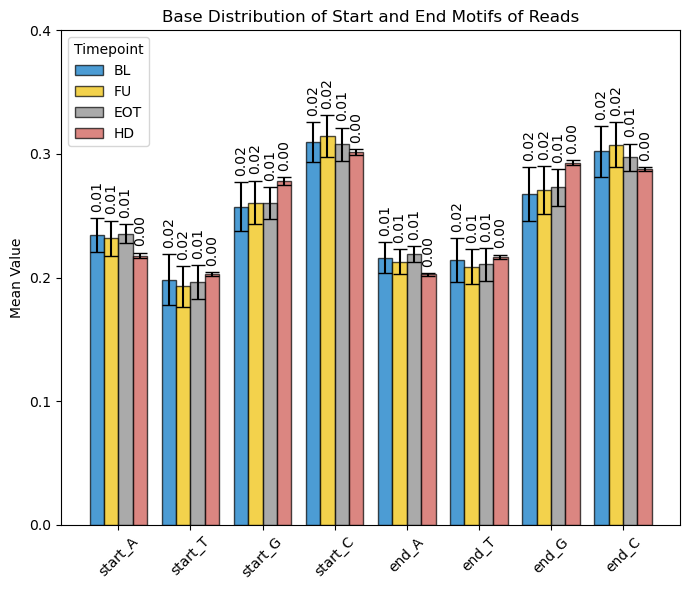

In [35]:
colors = {
    "BL": "#0073C2FF",    # JCO Blue
    "FU": "#EFC000FF",    # JCO Orange
    "EOT": "#868686FF",   # JCO Green
    "HD": "#CD534CFF"     # JCO Pink
}
bar_width = 0.2  # Width of each bar
index = np.arange(len(mean_base_frequency_per_timepoint.columns))  # X locations for the columns (A, T, G, C per start and end)

plt.figure(figsize=(7, 6))

# Plot each timepoint with offset positions for grouped bars
for i, (timepoint, color) in enumerate(colors.items()):
    mean_values = mean_base_frequency_per_timepoint.loc[timepoint]
    std_values = std_dev_base_frequency_per_timepoint.loc[timepoint]
    bar_positions = index + i * bar_width  # Offset position for each timepoint

    # Plot bars with error bars and customized appearance
    bars = plt.bar(bar_positions, mean_values, yerr=std_values, capsize=5, width=bar_width, color=color, edgecolor='black', alpha=0.7, label=timepoint)

    # Annotate each bar with the standard deviation value angled at 45°, positioned above the error bars
    for bar, std_dev in zip(bars, std_values):
        yval = bar.get_height() + std_dev + 0.005
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{std_dev:.2f}', ha='center', va='bottom', rotation=90)

# Customize the plot appearance
plt.ylabel('Mean Value')
plt.title('Base Distribution of Start and End Motifs of Reads')

# Set y-axis ticks at intervals of 0.1
plt.yticks(np.arange(0, 0.5, 0.1))

plt.xticks(index + bar_width * (len(colors) - 1) / 2, mean_base_frequency_per_timepoint.columns, rotation=45)
plt.legend(title="Timepoint")
plt.tight_layout()

# Show plot
plt.show()

calculate mean frequency of bases (A, T, G, C) for each of the first & last six positions of every read

In [36]:
# Get the list of files for each timepoint
BL_files_duplex = glob.glob("*_BL_duplex.csv")
FU_files_duplex = glob.glob("*_2CX_duplex.csv")
HD_files_duplex = glob.glob("*_HL_cfDNA_duplex.csv")
EOT_files_duplex = glob.glob("*_EOT_duplex.csv")  # Added EOT files

# Initialize an empty list to store DataFrames
all_dfs = []

# Function to calculate base percentages for A, T, G, C at positions 1 to 6
def calculate_percentages(column):
    # Extract the first 6 characters from each motif
    chars = column.str[:6].apply(list).explode().value_counts(normalize=True)
    return {
        f'{column.name}_1_A': chars.get('A', 0),
        f'{column.name}_1_T': chars.get('T', 0),
        f'{column.name}_1_G': chars.get('G', 0),
        f'{column.name}_1_C': chars.get('C', 0),
        f'{column.name}_2_A': chars.get('A', 0),
        f'{column.name}_2_T': chars.get('T', 0),
        f'{column.name}_2_G': chars.get('G', 0),
        f'{column.name}_2_C': chars.get('C', 0),
        f'{column.name}_3_A': chars.get('A', 0),
        f'{column.name}_3_T': chars.get('T', 0),
        f'{column.name}_3_G': chars.get('G', 0),
        f'{column.name}_3_C': chars.get('C', 0),
        f'{column.name}_4_A': chars.get('A', 0),
        f'{column.name}_4_T': chars.get('T', 0),
        f'{column.name}_4_G': chars.get('G', 0),
        f'{column.name}_4_C': chars.get('C', 0),
        f'{column.name}_5_A': chars.get('A', 0),
        f'{column.name}_5_T': chars.get('T', 0),
        f'{column.name}_5_G': chars.get('G', 0),
        f'{column.name}_5_C': chars.get('C', 0),
        f'{column.name}_6_A': chars.get('A', 0),
        f'{column.name}_6_T': chars.get('T', 0),
        f'{column.name}_6_G': chars.get('G', 0),
        f'{column.name}_6_C': chars.get('C', 0),
    }

# Generalized function to process files and handle timepoints
def process_files(duplex_files, timepoint_label):
    for file in duplex_files:
        # Get the patient ID from the file name (assuming a naming convention)
        patient = os.path.splitext(os.path.basename(file))[0][:-10]

        # Read CSV file into a DataFrame
        input_df = pd.read_csv(file)

        # Replace the template_length column with its absolute values
        input_df["template_length"] = input_df["template_length"].abs()

        # Define the bins for template length
        bins = np.arange(0, 1010, 10)  # 10 bp increments up to 1000 bp
        labels = [f'{i}-{i+10}' for i in bins[:-1]]  # Label each bin as '0-10', '10-20', etc.

        # Bin the template_length into defined bins
        input_df['Binned_Template_Length'] = pd.cut(input_df['template_length'], bins=bins, labels=labels, right=False)

        # Calculate the counts of reads in each bin
        binned_counts = input_df['Binned_Template_Length'].value_counts().sort_index().reindex(labels, fill_value=0)

        # Normalize the binned counts to get percentages
        binned_counts_normalized = binned_counts / binned_counts.sum()

        # Calculate the percentages for each base in start_motif and end_motif
        start_motif_perc = calculate_percentages(input_df['start_motif'])
        end_motif_perc = calculate_percentages(input_df['end_motif'])

        # Combine all calculated metrics into a single DataFrame row
        file_result = pd.DataFrame([{
            'ID': patient,
            'Timepoint': timepoint_label,
            **start_motif_perc,
            **end_motif_perc,
            **binned_counts_normalized.to_dict()
        }])

        # Append the DataFrame to the list
        all_dfs.append(file_result)

# Process HD, FU, BL, and EOT files for their respective timepoints
process_files(HD_files_duplex, "HD")
process_files(FU_files_duplex, "FU")
process_files(BL_files_duplex, "BL")
process_files(EOT_files_duplex, "EOT")  # Added this line for EOT files

# Concatenate all DataFrames in the list into a final DataFrame
final_df_per_sample_bases_per_pos = pd.concat(all_dfs, ignore_index=True)

# Define the file path where you want to save the CSV file
output_csv_file = "HD21_length_bins_base_distribution_per_pos_20241018.csv"

# Write the final DataFrame to a CSV file
final_df_per_sample_bases_per_pos.to_csv(output_csv_file, index=False)

print(f"Final dataframe saved to {output_csv_file}")

Final dataframe saved to HD21_length_bins_base_distribution_per_pos_20241018.csv


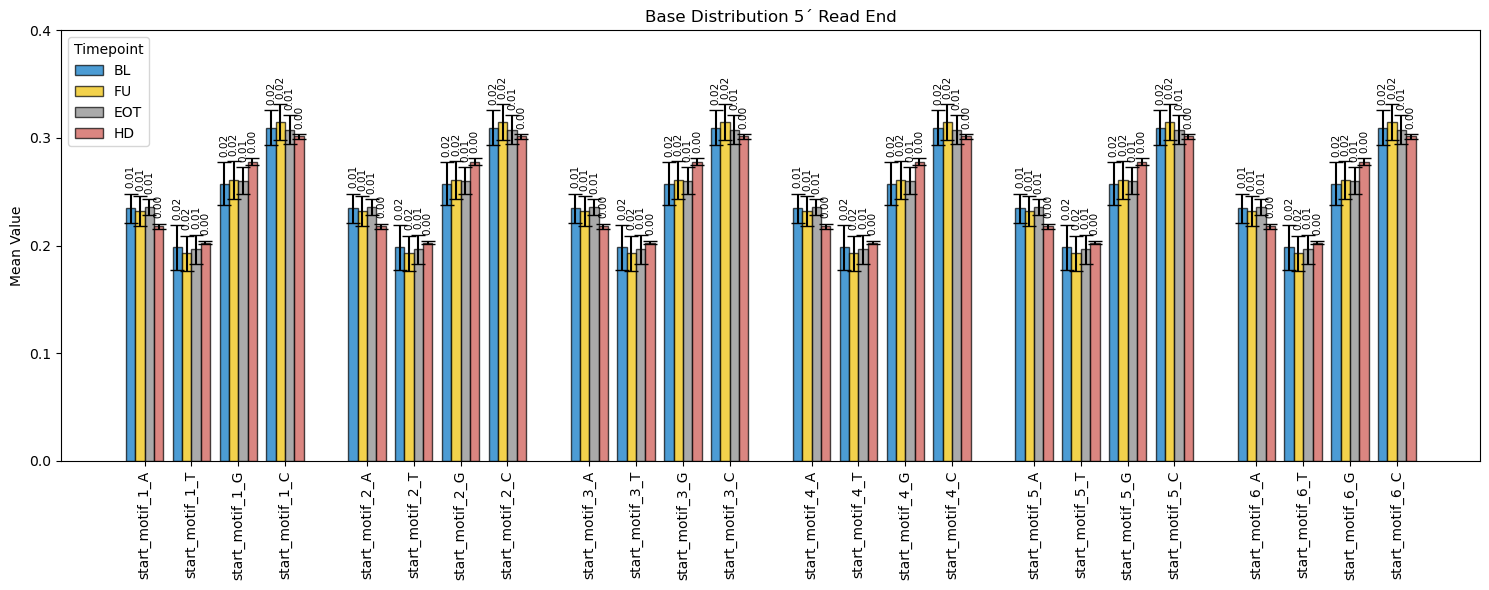

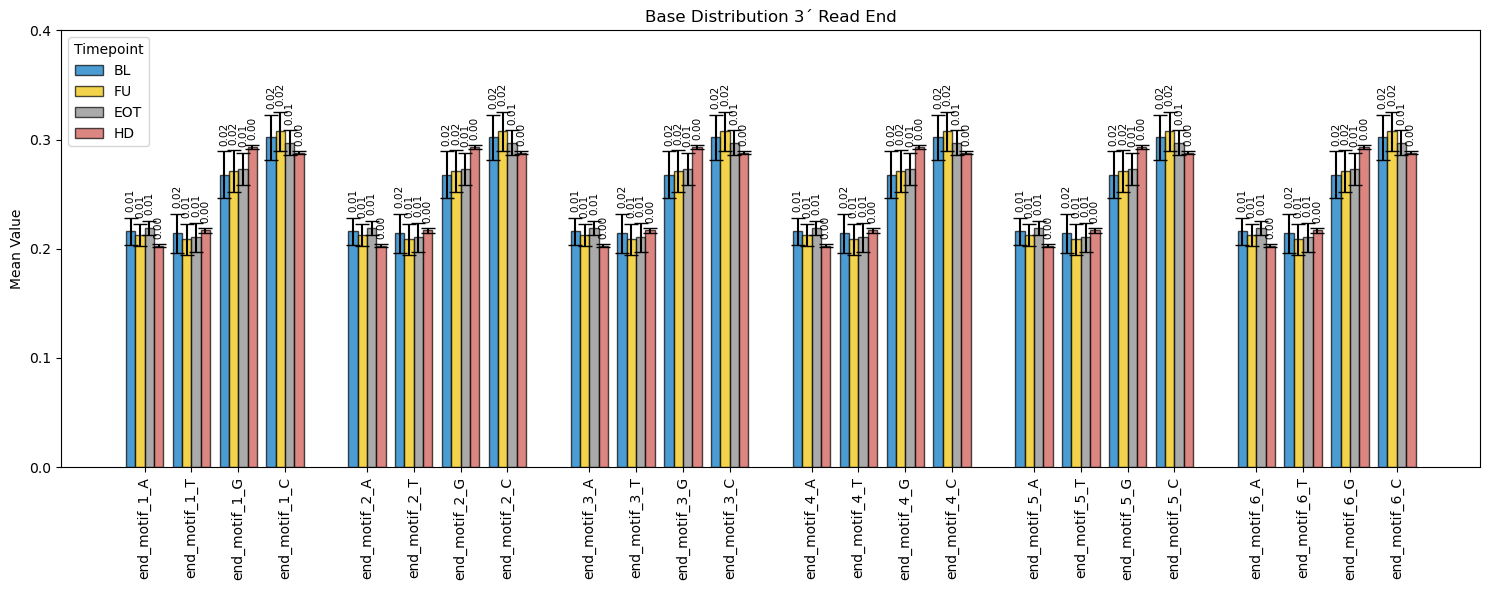

In [71]:
timepoint_groups = final_df_per_sample_bases_per_pos.groupby('Timepoint')

# Define the columns for start and end motifs separately
start_base_columns = [f'start_motif_{i}_{base}' for i in range(1, 6+1) for base in ['A', 'T', 'G', 'C']]
end_base_columns = [f'end_motif_{i}_{base}' for i in range(1, 6+1) for base in ['A', 'T', 'G', 'C']]

# Calculate mean and standard deviation for start and end motifs per group
mean_bases_start = timepoint_groups[start_base_columns].mean()
std_devs_start = timepoint_groups[start_base_columns].std()

mean_bases_end = timepoint_groups[end_base_columns].mean()
std_devs_end = timepoint_groups[end_base_columns].std()

colors = {
    "BL": "#0073C2FF",    # JCO Blue
    "FU": "#EFC000FF",    # JCO Orange
    "EOT": "#868686FF",   # JCO Green
    "HD": "#CD534CFF"     # JCO Pink
}
bar_width = 0.2  # Width of each bar

def add_extra_white_space(index, interval=4, extra_space=0.75):
    """
    Adds extra spacing after every 'interval' bars without adding divider lines.
    """
    spaced_index = []
    for i, idx in enumerate(index):
        # Add extra spacing after every 'interval' bars
        if (i + 1) % interval == 0:
            spaced_index.append(idx + (i // interval) * extra_space)  # Adjust the index by adding extra space
        else:
            spaced_index.append(idx + (i // interval) * extra_space)  # Continue the regular spacing
    
    return np.array(spaced_index)

### Plot for START motifs ###
index_start = np.arange(len(mean_bases_start.columns))  # X locations for the start motif columns
index_start_spaced = add_extra_white_space(index_start)  # Adding spaces every 4 groups

plt.figure(figsize=(15, 6))  # Adjust figure size as necessary

# Loop through timepoints and plot start motif data
for i, (timepoint, color) in enumerate(colors.items()):
    mean_bases = mean_bases_start.loc[timepoint]
    std_devs = std_devs_start.loc[timepoint]
    
    # Adjust x positions to spread bars for different timepoints
    bar_positions = index_start_spaced + i * bar_width

    # Plot bars with error bars
    bars = plt.bar(bar_positions, mean_bases, yerr=std_devs, capsize=5, width=bar_width, 
                   color=color, edgecolor='black', alpha=0.7, label=timepoint)

    # Annotate std values above error bars, angled at 90°
    for bar, std_dev in zip(bars, std_devs):
        yval = bar.get_height() + std_dev + 0.005
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{std_dev:.2f}', ha='center', va='bottom', rotation=90,fontsize=7.5)

# Customize plot for start motifs
plt.yticks(np.arange(0, 0.5, 0.1))
plt.ylabel('Mean Value')
plt.title('Base Distribution 5´ Read End')
plt.xticks(index_start_spaced + bar_width * (len(colors) - 1) / 2, mean_bases_start.columns, rotation=90)
plt.legend(title="Timepoint")
plt.tight_layout()
plt.show()

### Plot for END motifs ###
index_end = np.arange(len(mean_bases_end.columns))  # X locations for the end motif columns
index_end_spaced = add_extra_white_space(index_end)  # Adding spaces every 4 groups

plt.figure(figsize=(15, 6))  # Adjust figure size

# Loop through timepoints and plot end motif data
for i, (timepoint, color) in enumerate(colors.items()):
    mean_bases = mean_bases_end.loc[timepoint]
    std_devs = std_devs_end.loc[timepoint]

    # Adjust x positions to spread bars for different timepoints
    bar_positions = index_end_spaced + i * bar_width

    # Plot bars with error bars
    bars = plt.bar(bar_positions, mean_bases, yerr=std_devs, capsize=5, width=bar_width, 
                   color=color, edgecolor='black', alpha=0.7, label=timepoint)

    # Annotate std values above error bars, angled at 90°
    for bar, std_dev in zip(bars, std_devs):
        yval = bar.get_height() + std_dev + 0.005
        plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{std_dev:.2f}', ha='center', va='bottom', rotation=90,fontsize=7.5)

# Customize plot for end motifs
plt.yticks(np.arange(0, 0.5, 0.1))
plt.ylabel('Mean Value')
plt.title('Base Distribution 3´ Read End')
plt.xticks(index_end_spaced + bar_width * (len(colors) - 1) / 2, mean_bases_end.columns, rotation=90)
plt.legend(title="Timepoint")
plt.tight_layout()
plt.show()

plot 3mers

In [65]:
# Combine all duplex files into one list
duplex_files = BL_files_duplex + FU_files_duplex + HD_files_duplex + EOT_files_duplex  # Include EOT files

# Initialize an empty list to store DataFrames
all_dfs = []

# Define possible 3-character motifs
motifs = [
    'AAA', 'AAT', 'AAC', 'AAG',
    'ATA', 'ATT', 'ATC', 'ATG',
    'ACA', 'ACT', 'ACC', 'ACG',
    'AGA', 'AGT', 'AGC', 'AGG',
    'TAA', 'TAT', 'TAC', 'TAG',
    'TTA', 'TTT', 'TTC', 'TTG',
    'TCA', 'TCT', 'TCC', 'TCG',
    'TGA', 'TGT', 'TGC', 'TGG',
    'CAA', 'CAT', 'CAC', 'CAG',
    'CTA', 'CTT', 'CTC', 'CTG',
    'CCA', 'CCT', 'CCC', 'CCG',
    'CGA', 'CGT', 'CGC', 'CGG',
    'GAA', 'GAT', 'GAC', 'GAG',
    'GTA', 'GTT', 'GTC', 'GTG',
    'GCA', 'GCT', 'GCC', 'GCG',
    'GGA', 'GGT', 'GGC', 'GGG'
]

# Loop through files
for file in duplex_files:
    # Get the file name (patient identifier)
    patient = os.path.splitext(os.path.basename(file))[0][:-10]
    
    # Determine the timepoint from the file name
    if "_BL_" in file:
        timepoint = "BL"
    elif "_HL_" in file:
        timepoint = "HD"
    elif "_2CX_" in file:
        timepoint = "FU"
    elif "_EOT_" in file:  # Added EOT timepoint check
        timepoint = "EOT"
    else:
        timepoint = "Unknown"  # Default if timepoint isn't clear

    # Read CSV files into Pandas dataframe
    input_df = pd.read_csv(file, low_memory=False)

    # Filter input for phased reads and duplex reads = reads from the tumor
    filtered_duplex_reads = input_df.loc[:, ["template_length", "start_motif", "end_motif"]]

    # Replace the template_length column with its absolute values
    filtered_duplex_reads["template_length"] = filtered_duplex_reads["template_length"].abs()

    # Define the bins
    bins = np.arange(0, 1010, 10)
    labels = [f'{i}-{i+10}' for i in bins[:-1]]

    # Bin the template_length
    filtered_duplex_reads['Binned_Template_Length'] = pd.cut(filtered_duplex_reads['template_length'], bins=bins, labels=labels, right=False)

    # Calculate the counts of reads in each bin
    binned_counts = filtered_duplex_reads['Binned_Template_Length'].value_counts().sort_index().reindex(labels, fill_value=0)

    # Normalize the binned counts to get percentages
    binned_counts_normalized = binned_counts / binned_counts.sum()

    # Calculate the percentages for each motif in start_motif and end_motif
    def calculate_percentages(column):
        # Extract the first 3 characters of each motif
        chars = column.str[:3].value_counts(normalize=True)
        return {f'{column.name}_{motif}': chars.get(motif, 0) for motif in motifs}

    # Calculate percentages for start and end motifs
    start_motif_perc = calculate_percentages(filtered_duplex_reads['start_motif'])
    end_motif_perc = calculate_percentages(filtered_duplex_reads['end_motif'])

    # Normalize the start and end motif percentages separately to sum to 1 each
    start_motif_sum = sum(start_motif_perc.values())
    end_motif_sum = sum(end_motif_perc.values())

    if start_motif_sum > 0:
        start_motif_perc = {k: v / start_motif_sum for k, v in start_motif_perc.items()}
    if end_motif_sum > 0:
        end_motif_perc = {k: v / end_motif_sum for k, v in end_motif_perc.items()}

    # Combine all calculated metrics into a single DataFrame row
    file_result = pd.DataFrame([{
        'ID': patient,
        'Timepoint': timepoint,
        **start_motif_perc,
        **end_motif_perc,
        **binned_counts_normalized,
        'number_reads': len(filtered_duplex_reads)  # Add the number of reads for the sample
    }])

    # Add a column with the row sum of all bins
    file_result['Row_Sum'] = binned_counts_normalized.sum()

    # Append the DataFrame to the list
    all_dfs.append(file_result)

# Concatenate all DataFrames in the list
motifs_per_sample = pd.concat(all_dfs, ignore_index=True)

# Define the file path where you want to save the CSV file
output_csv_file = "3mer_motifs_per_sample_with_timepoints_HD21_20241018.csv"

# Write the final DataFrame to a CSV file
motifs_per_sample.to_csv(output_csv_file, index=False)

print(f"Final dataframe saved to {output_csv_file}")

Final dataframe saved to 3mer_motifs_per_sample_with_timepoints_HD21_20241018.csv


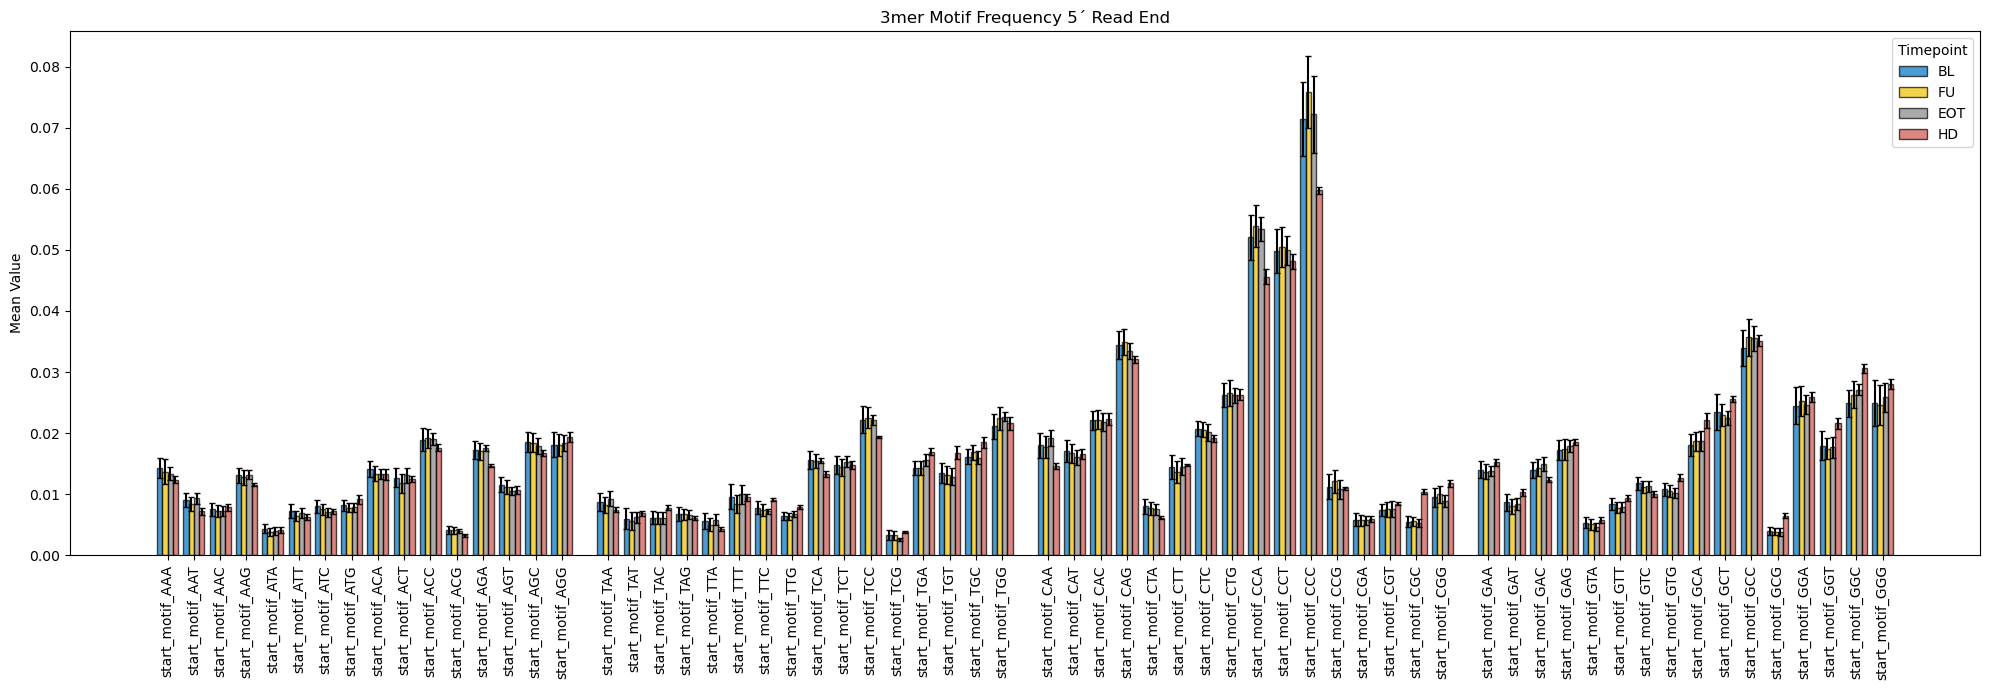

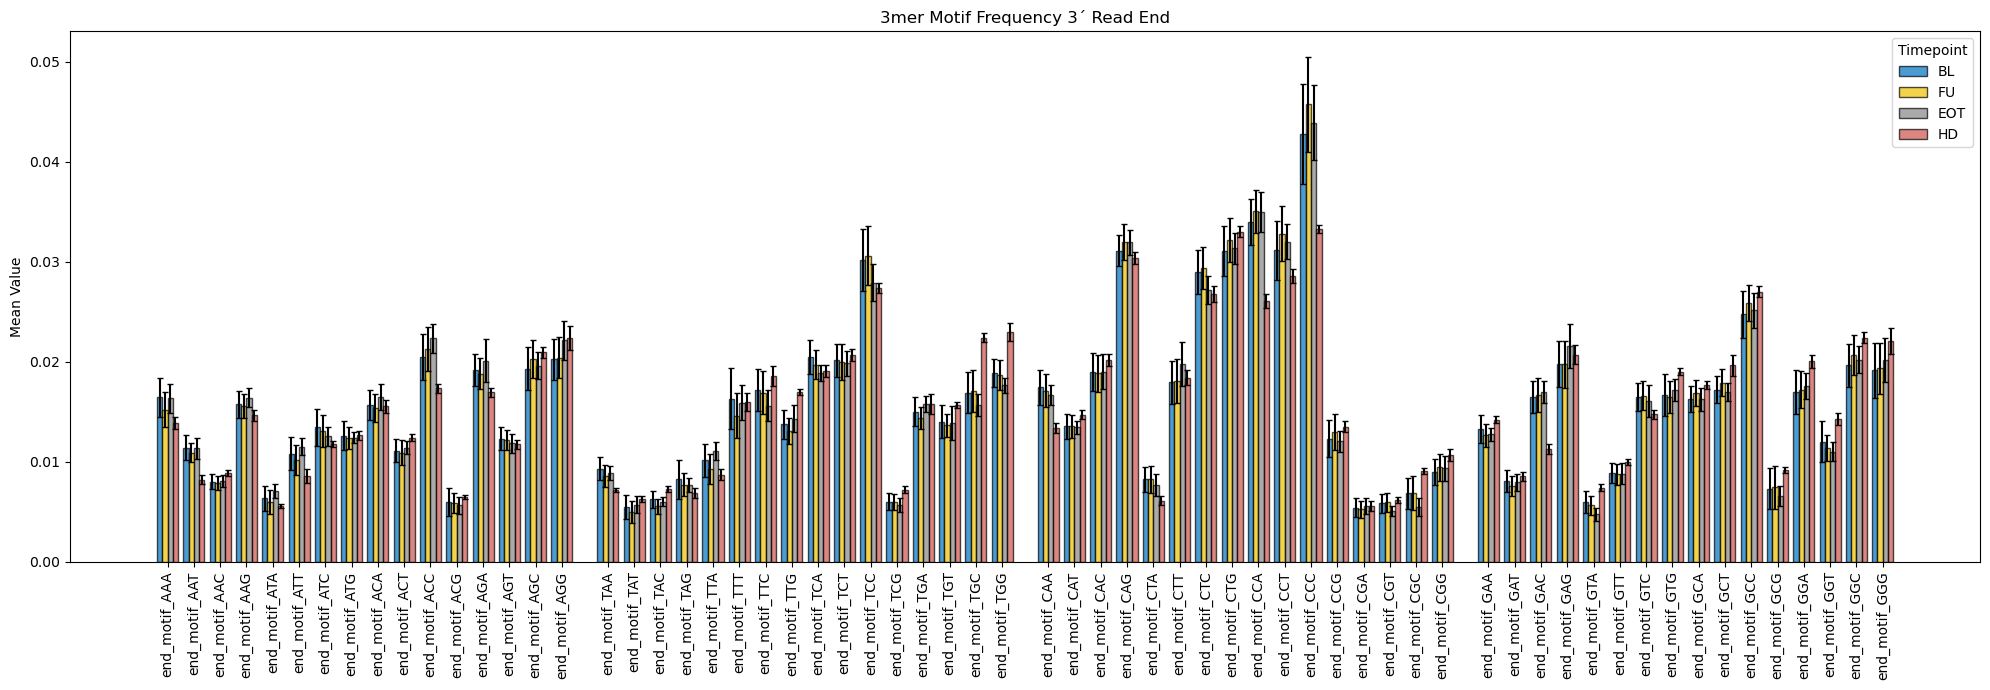

In [ ]:
# Filter columns for start motifs and end motifs
start_columns = [col for col in motifs_per_sample.columns if 'start_motif' in col]
end_columns = [col for col in motifs_per_sample.columns if 'end_motif' in col]

# Group by Timepoint and calculate the mean and standard deviation for start and end motifs
mean_start_motifs_per_group = motifs_per_sample.groupby('Timepoint')[start_columns].mean()
std_devs_start_motifs_per_group = motifs_per_sample.groupby('Timepoint')[start_columns].std()

mean_end_motifs_per_group = motifs_per_sample.groupby('Timepoint')[end_columns].mean()
std_devs_end_motifs_per_group = motifs_per_sample.groupby('Timepoint')[end_columns].std()

# Set up the color mapping for each timepoint in the specified order
colors = {
    "BL": "#0073C2FF",    # JCO Blue
    "FU": "#EFC000FF",    # JCO Orange
    "EOT": "#868686FF",   # JCO Green
    "HD": "#CD534CFF"     # JCO Pink
}

# Define the timepoints in the required order
ordered_timepoints = ["BL", "FU", "EOT", "HD"]

# Scale factor for yerr to reduce error bar size
error_bar_scale = 0.5  # Adjust this as needed to scale down the error bars

# Function to add extra white space after every 'interval' groups
def add_extra_white_space(index, interval=16, extra_space=0.75):
    """
    Adds extra spacing after every 'interval' bars without adding divider lines.
    """
    spaced_index = []
    for i, idx in enumerate(index):
        # Add extra spacing after every 'interval' bars
        if (i + 1) % interval == 0:
            spaced_index.append(idx + (i // interval) * extra_space)  # Adjust the index by adding extra space
        else:
            spaced_index.append(idx + (i // interval) * extra_space)  # Continue the regular spacing
    
    return np.array(spaced_index)

# Plot for start motifs
n_timepoints = len(colors)
bar_width = 0.2  # Width of each bar
index_start = np.arange(len(mean_start_motifs_per_group.columns))  # The x locations for the start motifs
index_start_spaced = add_extra_white_space(index_start)  # Adding spaces every 16 motifs

plt.figure(figsize=(20, 7))

# Loop through the groups and plot each one with a different offset position in the specified order
for i, timepoint in enumerate(ordered_timepoints):
    if timepoint not in mean_start_motifs_per_group.index:
        print(f"Timepoint '{timepoint}' not found, skipping.")
        continue
    
    color = colors[timepoint]

    # Calculate the position of the bars for this timepoint
    mean_motifs = mean_start_motifs_per_group.loc[timepoint]
    std_devs = std_devs_start_motifs_per_group.loc[timepoint] * error_bar_scale  # Scale down std_devs

    # Adjust the x positions to spread the bars for different timepoints
    bar_positions = index_start_spaced + i * bar_width

    # Plot the bars with smaller error bars
    bars = plt.bar(bar_positions, mean_motifs, yerr=std_devs, capsize=2, width=bar_width, color=color, edgecolor='black', alpha=0.7, label=timepoint)

# Customize the plot for start motifs
plt.ylabel('Mean Value')
plt.title('3mer Motif Frequency 5´ Read End')

# Set the x-ticks to be in the center of grouped bars
plt.xticks(index_start_spaced + bar_width * (n_timepoints - 1) / 2, mean_start_motifs_per_group.columns, rotation=90)

plt.legend(title="Timepoint")
plt.tight_layout()
plt.show()

### Plot for end motifs ###
index_end = np.arange(len(mean_end_motifs_per_group.columns))  # The x locations for the end motifs
index_end_spaced = add_extra_white_space(index_end)  # Adding spaces every 16 motifs

plt.figure(figsize=(20, 7))

# Loop through the groups and plot each one with a different offset position in the specified order
for i, timepoint in enumerate(ordered_timepoints):
    if timepoint not in mean_end_motifs_per_group.index:
        print(f"Timepoint '{timepoint}' not found, skipping.")
        continue
    
    color = colors[timepoint]

    # Calculate the position of the bars for this timepoint
    mean_motifs = mean_end_motifs_per_group.loc[timepoint]
    std_devs = std_devs_end_motifs_per_group.loc[timepoint] * error_bar_scale  # Scale down std_devs

    # Adjust the x positions to spread the bars for different timepoints
    bar_positions = index_end_spaced + i * bar_width

    # Plot the bars with smaller error bars
    bars = plt.bar(bar_positions, mean_motifs, yerr=std_devs, capsize=2, width=bar_width, color=color, edgecolor='black', alpha=0.7, label=timepoint)

# Customize the plot for end motifs
plt.ylabel('Mean Value')
plt.title('3mer Motif Frequency 3´ Read End')

# Set the x-ticks to be in the center of grouped bars
plt.xticks(index_end_spaced + bar_width * (n_timepoints - 1) / 2, mean_end_motifs_per_group.columns, rotation=90)

plt.legend(title="Timepoint")
plt.tight_layout()
plt.show()


plot 3mers per chr

In [115]:
# Initialize an empty list to store DataFrames
all_dfs = []

# Define possible 3-character motifs
motifs = [
    'AAA', 'AAT', 'AAC', 'AAG', 'ATA', 'ATT', 'ATC', 'ATG',
    'ACA', 'ACT', 'ACC', 'ACG', 'AGA', 'AGT', 'AGC', 'AGG',
    'TAA', 'TAT', 'TAC', 'TAG', 'TTA', 'TTT', 'TTC', 'TTG',
    'TCA', 'TCT', 'TCC', 'TCG', 'TGA', 'TGT', 'TGC', 'TGG',
    'CAA', 'CAT', 'CAC', 'CAG', 'CTA', 'CTT', 'CTC', 'CTG',
    'CCA', 'CCT', 'CCC', 'CCG', 'CGA', 'CGT', 'CGC', 'CGG',
    'GAA', 'GAT', 'GAC', 'GAG', 'GTA', 'GTT', 'GTC', 'GTG',
    'GCA', 'GCT', 'GCC', 'GCG', 'GGA', 'GGT', 'GGC', 'GGG'
]

# Define bins for template length
bins = np.arange(0, 1010, 10)
labels = [f'{i}-{i+10}' for i in bins[:-1]]

# Helper function to calculate motif percentages
def calculate_percentages(column):
    if column.isnull().all():  # If column is empty, return zeros for all motifs
        return {f'{column.name}_{motif}': 0 for motif in motifs}
    
    # Calculate the 3-character motif frequency
    chars = column.str[:3].value_counts(normalize=True)
    return {f'{column.name}_{motif}': chars.get(motif, 0) for motif in motifs}

# Loop through files
for file in duplex_files:
    try:
        # Get the patient ID from the file name (assumes last 10 chars are "_duplex.csv")
        patient = os.path.splitext(os.path.basename(file))[0][:-10]

        # Determine the timepoint from the file name
        if "_BL_" in file:
            timepoint = "BL"
        elif "_HL_" in file:
            timepoint = "HD"
        elif "_2CX_" in file:
            timepoint = "FU"
        elif "_EOT_" in file:  # Handle EOT timepoint
            timepoint = "EOT"
        else:
            timepoint = "Unknown"

        # Read CSV file into Pandas dataframe, use low_memory=False to avoid type guessing issues
        input_df = pd.read_csv(file, low_memory=False)

        # Ensure the necessary columns exist
        if 'template_length' not in input_df.columns or 'chr' not in input_df.columns:
            print(f"Skipping file {file} due to missing columns.")
            continue

        # Replace template_length with its absolute values
        input_df["template_length"] = input_df["template_length"].abs()

        # Bin the template_length
        input_df['Binned_Template_Length'] = pd.cut(input_df['template_length'], bins=bins, labels=labels, right=False)

        # Check if the columns 'start_motif' and 'end_motif' exist
        if 'start_motif' not in input_df.columns or 'end_motif' not in input_df.columns:
            print(f"Skipping file {file} due to missing motif columns.")
            continue

        # Extract unique chromosomes from the dataframe
        chromosomes = input_df['chr'].unique()

        # Loop through each chromosome
        for chr in chromosomes:
            # Filter rows by chromosome
            chr_df = input_df[input_df['chr'] == chr]

            # Calculate the counts of reads in each bin
            binned_counts = chr_df['Binned_Template_Length'].value_counts().sort_index().reindex(labels, fill_value=0)

            # Normalize the binned counts to get percentages
            binned_counts_normalized = binned_counts / binned_counts.sum()

            # Calculate percentages for start and end motifs
            start_motif_perc = calculate_percentages(chr_df['start_motif'])
            end_motif_perc = calculate_percentages(chr_df['end_motif'])

            # Normalize the motif percentages so that the sum equals 1
            start_sum = sum(start_motif_perc.values())
            end_sum = sum(end_motif_perc.values())

            if start_sum > 0:
                start_motif_perc = {k: v / start_sum for k, v in start_motif_perc.items()}
            if end_sum > 0:
                end_motif_perc = {k: v / end_sum for k, v in end_motif_perc.items()}

            # Combine all calculated metrics into a single DataFrame row
            file_result = pd.DataFrame([{
                'ID': patient,
                'Timepoint': timepoint,
                'chr': chr,  # Add the chromosome column
                **start_motif_perc,
                **end_motif_perc,
                **binned_counts_normalized,
                'number_reads': len(chr_df)  # Add the number of reads for the sample per chromosome
            }])

            # Append the DataFrame to the list
            all_dfs.append(file_result)

    except Exception as e:
        print(f"Error processing file {file}: {e}")

# Concatenate all DataFrames in the list
if all_dfs:
    bases_motifs_per_chr_per_sample = pd.concat(all_dfs, ignore_index=True)

    # Define the file path where you want to save the CSV file
    output_csv_file = "HD_HD21_length_bins_sep_motifs_per_chr_20241018.csv"

    # Write the final DataFrame to a CSV file
    bases_motifs_per_chr_per_sample.to_csv(output_csv_file, index=False)

    print(f"Final dataframe saved to {output_csv_file}")
else:
    print("No data processed.")

bases_motifs_per_chr_per_sample

Final dataframe saved to HD_HD21_length_bins_sep_motifs_per_chr_20241018.csv


,ID,Timepoint,chr,start_motif_AAA,start_motif_AAT,start_motif_AAC,start_motif_AAG,start_motif_ATA,start_motif_ATT,start_motif_ATC,...,910-920,920-930,930-940,940-950,950-960,960-970,970-980,980-990,990-1000,number_reads
0,39601,BL,chr3,0.027964,0.007892,0.012180,0.007205,0.009779,0.005318,0.004804,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5829
1,39601,BL,chr14,0.015508,0.008583,0.009009,0.013301,0.002330,0.003685,0.007873,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,105557
2,39601,BL,chr2,0.028217,0.027548,0.020354,0.013250,0.008894,0.018980,0.015817,...,0.0,0.000072,0.0,0.0,0.000163,0.0,0.0,0.0,0.0,55321
3,39601,BL,chr22,0.006923,0.005182,0.003603,0.014778,0.006114,0.009535,0.007429,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,49398
4,39601,BL,chr16,0.015491,0.002966,0.005736,0.017091,0.002614,0.001249,0.006282,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,25627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426,40495_,EOT,chr3,0.025499,0.013552,0.013730,0.013909,0.001070,0.003388,0.021041,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,5608
1427,40495_,EOT,chr11,0.027926,0.000000,0.000000,0.008644,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1504
1428,40495_,EOT,chr17,0.000000,0.000000,0.000000,0.003021,0.000000,0.010574,0.010574,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,662
1429,40495_,EOT,chr18,0.082411,0.011685,0.033210,0.042435,0.011685,0.000000,0.003075,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1626


plot 3mers differentiate into mono-, di- and tri-nucleosomes

In [118]:
# Define possible 3-character motifs
motifs = [
    'AAA', 'AAT', 'AAC', 'AAG', 'ATA', 'ATT', 'ATC', 'ATG',
    'ACA', 'ACT', 'ACC', 'ACG', 'AGA', 'AGT', 'AGC', 'AGG',
    'TAA', 'TAT', 'TAC', 'TAG', 'TTA', 'TTT', 'TTC', 'TTG',
    'TCA', 'TCT', 'TCC', 'TCG', 'TGA', 'TGT', 'TGC', 'TGG',
    'CAA', 'CAT', 'CAC', 'CAG', 'CTA', 'CTT', 'CTC', 'CTG',
    'CCA', 'CCT', 'CCC', 'CCG', 'CGA', 'CGT', 'CGC', 'CGG',
    'GAA', 'GAT', 'GAC', 'GAG', 'GTA', 'GTT', 'GTC', 'GTG',
    'GCA', 'GCT', 'GCC', 'GCG', 'GGA', 'GGT', 'GGC', 'GGG'
]

# Define nucleosomal ranges
mono_range = (0, 160)
di_range = (161, 320)
tri_range = (321, 480)

# Function to filter based on nucleosome size
def filter_nucleosomes(df, size_range):
    return df[(df['template_length'] > size_range[0]) & (df['template_length'] <= size_range[1])]

# Initialize list to store DataFrames
all_dfs = []

# Function to determine timepoint based on file name
def get_timepoint(file):
    if "_BL_" in file:
        return "BL"
    elif "_HL_" in file:
        return "HD"
    elif "_2CX_" in file:
        return "FU"
    elif "_EOT_" in file:
        return "EOT"
    else:
        return "Unknown"

# Find duplex files based on patterns
duplex_files = glob.glob("*_duplex.csv")  # Include all duplex files

# Process each file
for file in duplex_files:
    # Get the patient ID and timepoint
    patient = os.path.splitext(os.path.basename(file))[0][:-10]
    timepoint = get_timepoint(file)

    # Read CSV file into a Pandas dataframe
    input_df = pd.read_csv(file)

    # Check if the expected columns exist
    if 'template_length' not in input_df.columns or 'start_motif' not in input_df.columns or 'end_motif' not in input_df.columns:
        print(f"Expected columns not found in {file}. Skipping this file.")
        continue

    # Replace the template_length column with its absolute values
    input_df["template_length"] = input_df["template_length"].abs()

    # Split into mono-, di-, and tri-nucleosomal datasets
    mono_df = filter_nucleosomes(input_df, mono_range)
    di_df = filter_nucleosomes(input_df, di_range)
    tri_df = filter_nucleosomes(input_df, tri_range)

    # Function to calculate motif percentages
    def calculate_percentages(column):
        motif_counts = {motif: 0 for motif in motifs}
        motif_counts.update(column.str[:3].value_counts(normalize=True))
        return motif_counts

    # Function to process and create DataFrame for each nucleosome type
    def process_nucleosome_data(nuc_df, nuc_type):
        # Calculate the percentages for each 3-mer motif in start_motif and end_motif
        start_motif_perc = calculate_percentages(nuc_df['start_motif'])
        end_motif_perc = calculate_percentages(nuc_df['end_motif'])

        # Normalize start_motif and end_motif percentages
        start_sum = sum(start_motif_perc.values())
        end_sum = sum(end_motif_perc.values())

        if start_sum > 0:
            start_motif_perc = {k: v / start_sum for k, v in start_motif_perc.items()}
        if end_sum > 0:
            end_motif_perc = {k: v / end_sum for k, v in end_motif_perc.items()}

        # Combine all calculated metrics into a single DataFrame row
        return pd.DataFrame([{
            'ID': patient,
            'Timepoint': timepoint,
            'Nucleosome_Type': nuc_type,  # Add the nucleosome type
            # Start motif percentages
            **{f'start_{k}': v for k, v in start_motif_perc.items()},
            # End motif percentages
            **{f'end_{k}': v for k, v in end_motif_perc.items()},
            'number_reads': len(nuc_df)  # Add the number of reads
        }])

    # Process and append each nucleosome type's DataFrame
    all_dfs.append(process_nucleosome_data(mono_df, 'Mono-nucleosomal'))
    all_dfs.append(process_nucleosome_data(di_df, 'Di-nucleosomal'))
    all_dfs.append(process_nucleosome_data(tri_df, 'Tri-nucleosomal'))

# Concatenate all DataFrames in the list
motifs_per_sample_per_nucleosome = pd.concat(all_dfs, ignore_index=True)


In [119]:
motifs_per_sample_per_nucleosome.head()

,ID,Timepoint,Nucleosome_Type,start_AAA,start_AAT,start_AAC,start_AAG,start_ATA,start_ATT,start_ATC,...,end_GTG,end_GCA,end_GCT,end_GCC,end_GCG,end_GGA,end_GGT,end_GGC,end_GGG,number_reads
0,39601_,FU,Mono-nucleosomal,0.013925,0.011102,0.010476,0.012648,0.004727,0.008049,0.008470,...,0.016263,0.016404,0.015663,0.030355,0.005800,0.017618,0.013414,0.023034,0.021910,78274
1,39601_,FU,Di-nucleosomal,0.014998,0.011811,0.010023,0.012342,0.003747,0.007161,0.009105,...,0.016246,0.017765,0.017419,0.026496,0.006189,0.016106,0.010946,0.020689,0.018898,242832
2,39601_,FU,Tri-nucleosomal,0.014871,0.012384,0.011801,0.011828,0.004022,0.007594,0.007303,...,0.014421,0.017914,0.016300,0.024529,0.006324,0.014712,0.010796,0.020692,0.017967,37792
3,39601,BL,Mono-nucleosomal,0.017588,0.011768,0.010309,0.014058,0.004539,0.008899,0.008709,...,0.015478,0.016298,0.015988,0.027726,0.006009,0.018517,0.012698,0.022357,0.023257,100014
4,39601,BL,Di-nucleosomal,0.017149,0.011506,0.010366,0.013433,0.004748,0.007832,0.009218,...,0.015205,0.017304,0.016173,0.025087,0.006159,0.017764,0.012663,0.018822,0.020897,121934


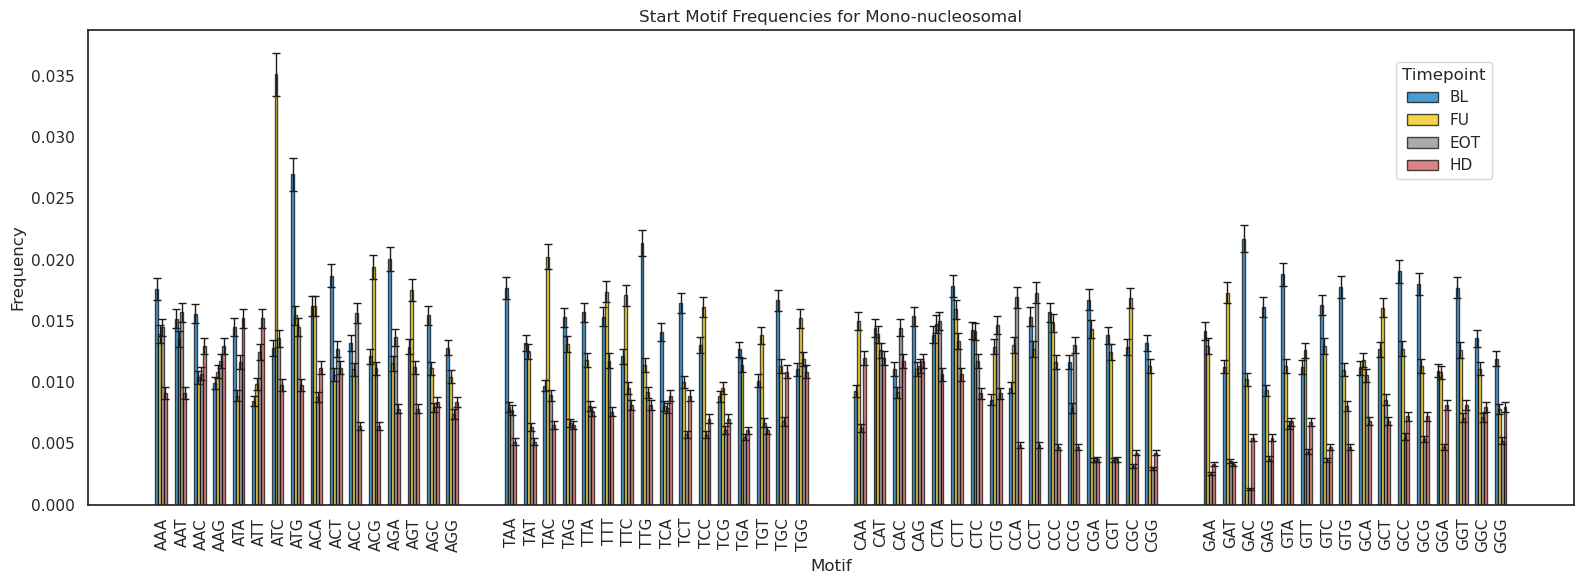

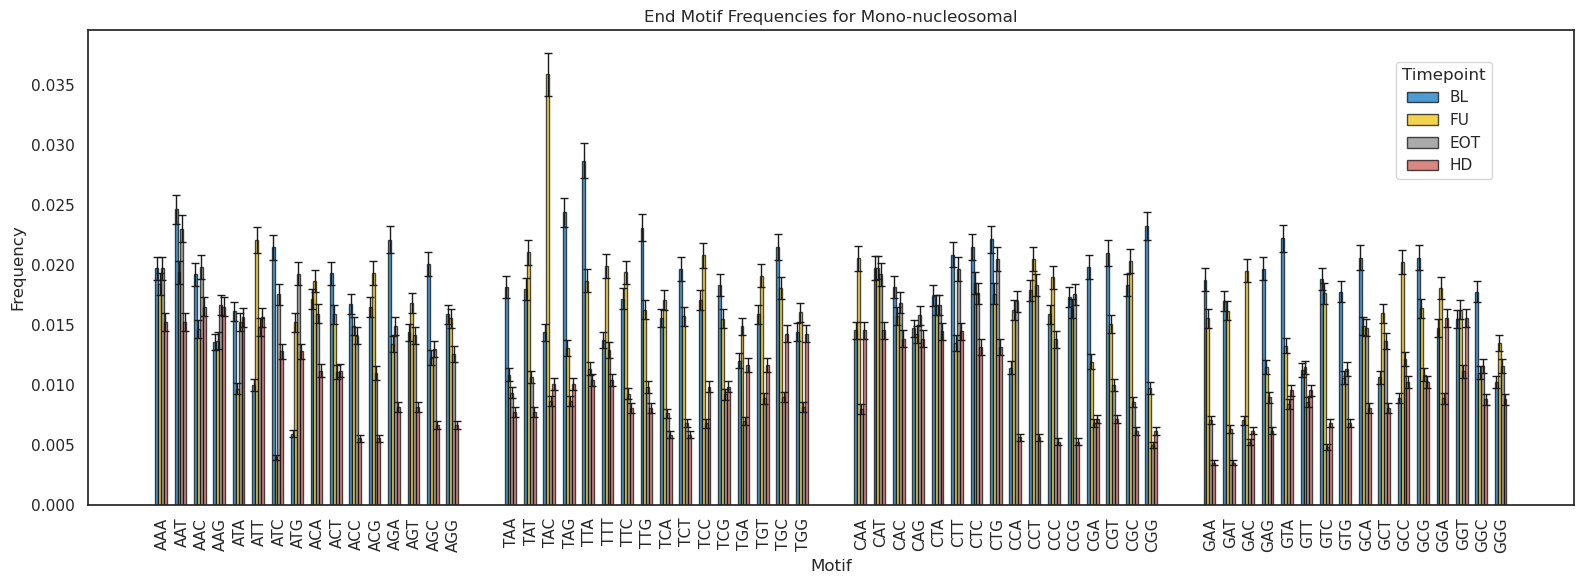

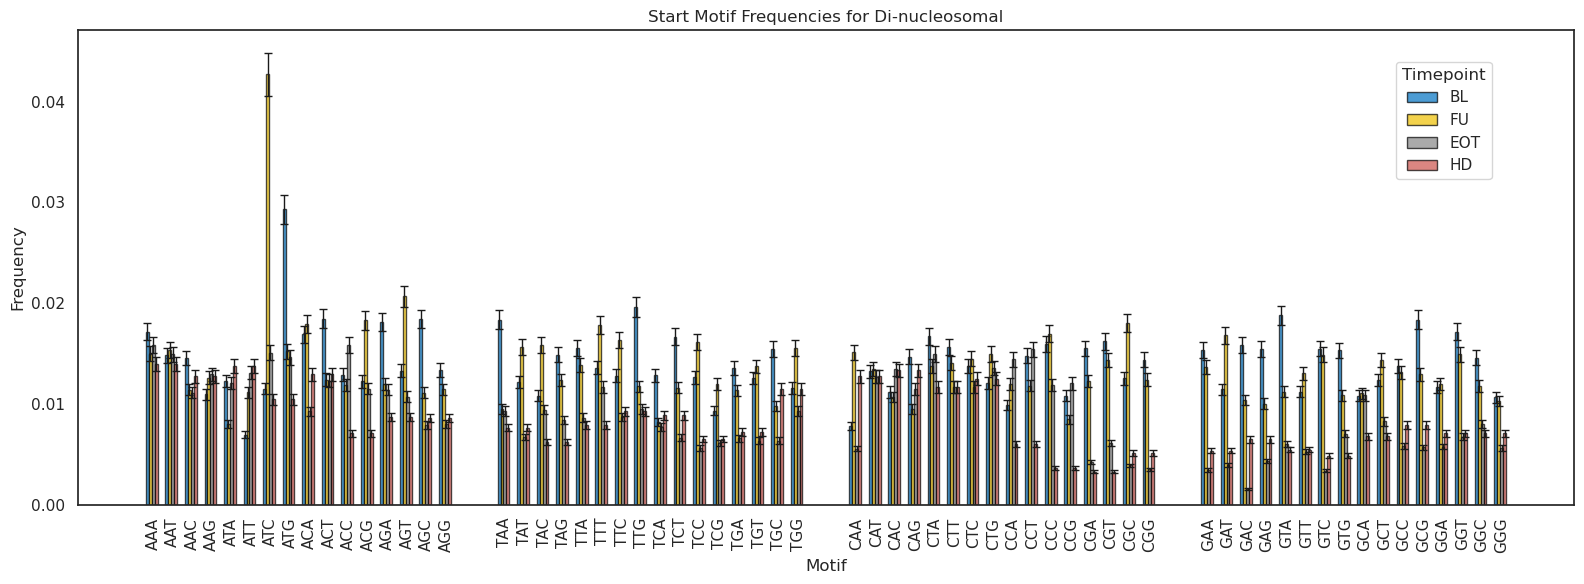

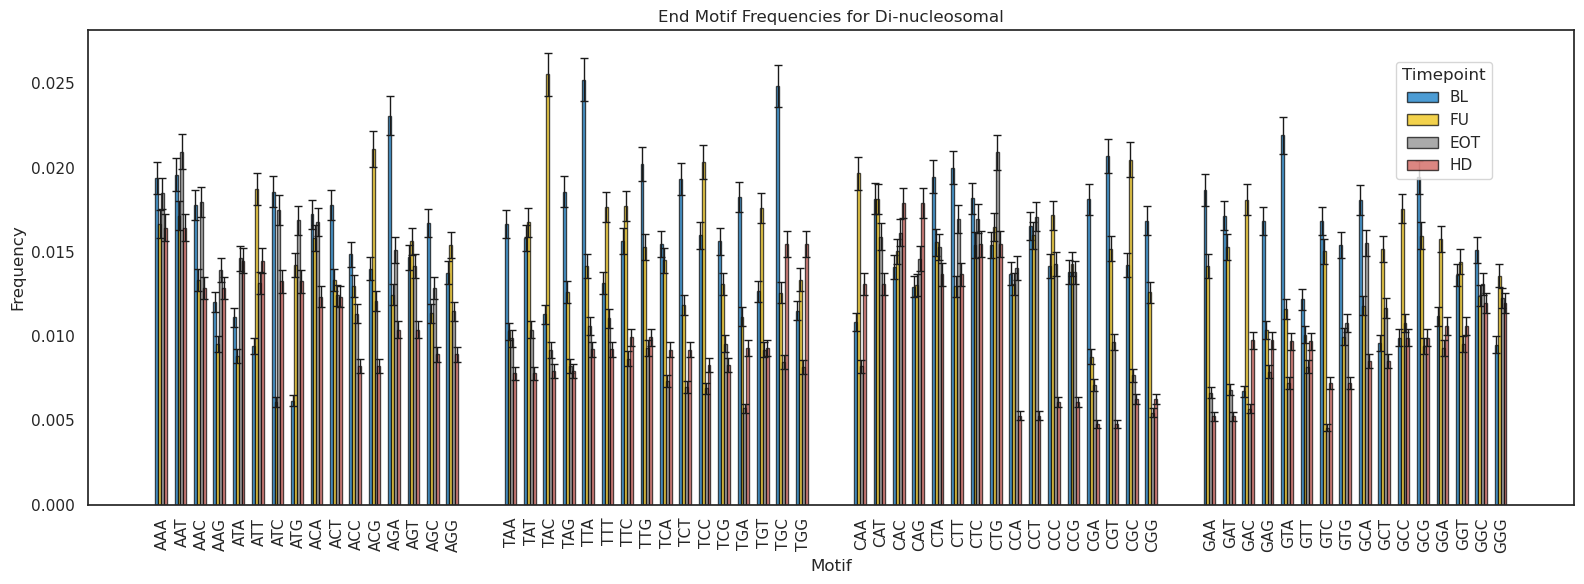

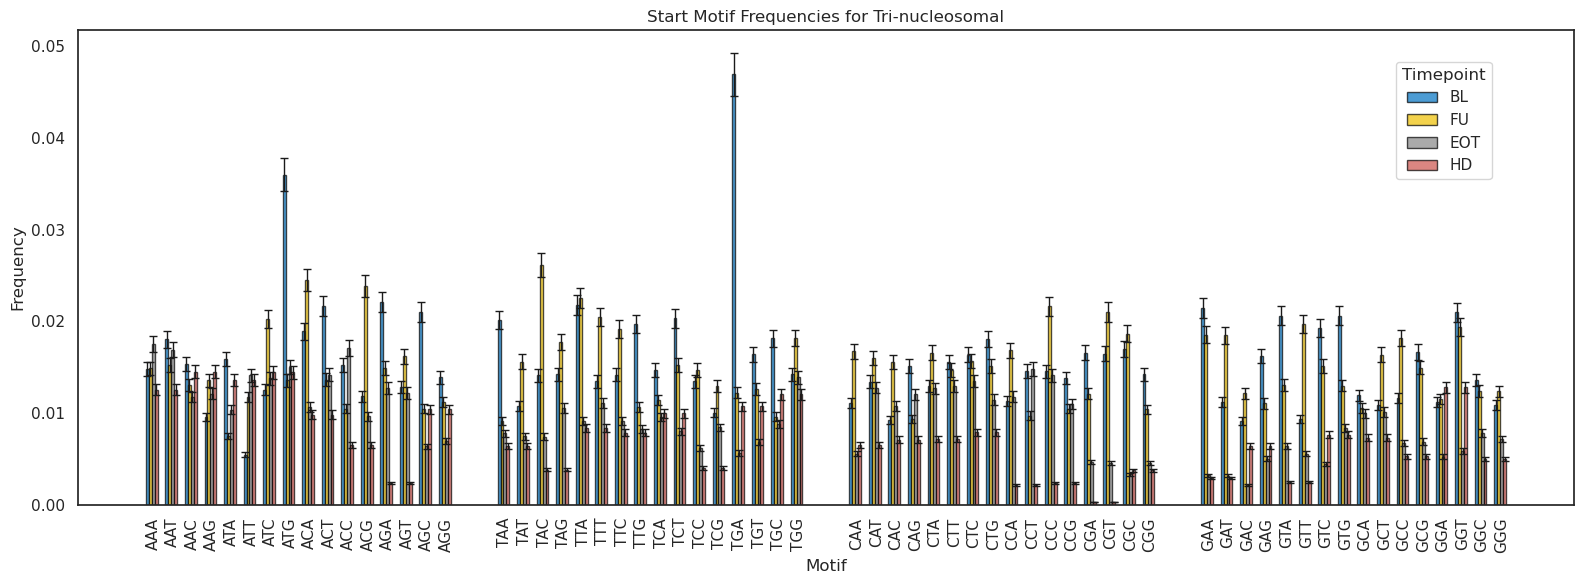

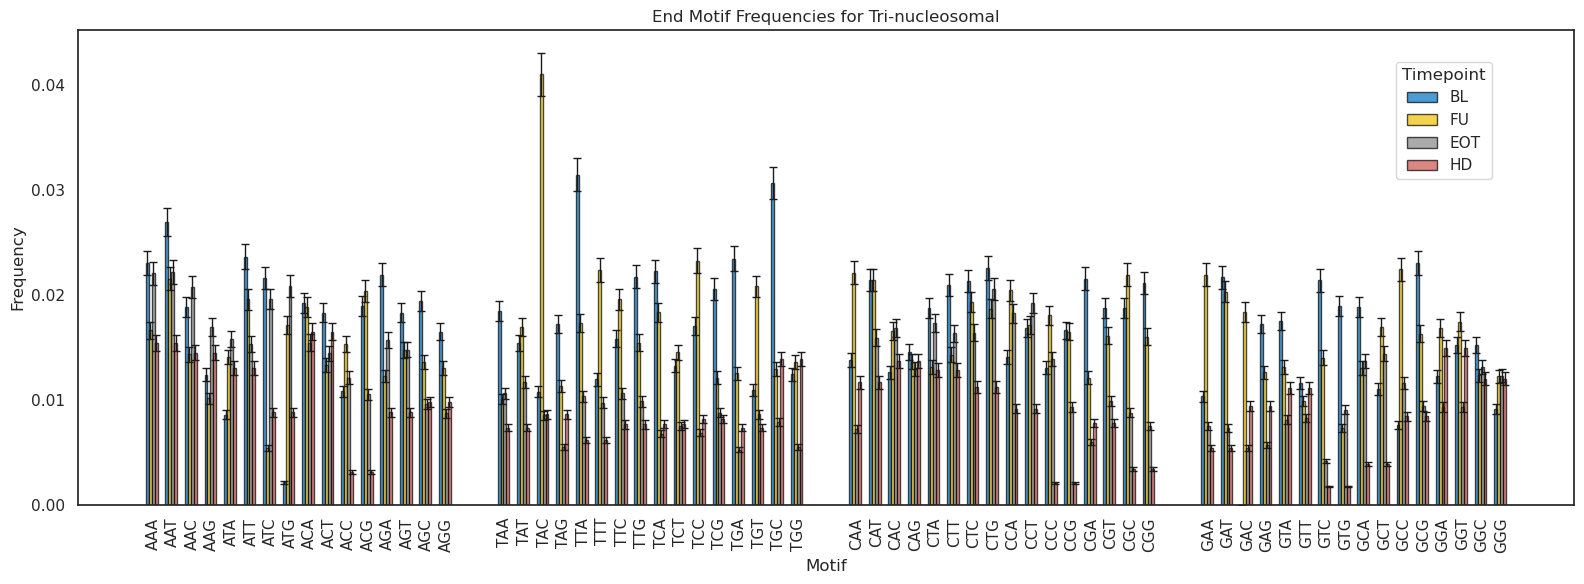

In [138]:
colors = {
    "BL": "#0073C2FF",    # JCO Blue
    "FU": "#EFC000FF",    # JCO Orange
    "EOT": "#868686FF",   # JCO Green
    "HD": "#CD534CFF"     # JCO Pink
}

# Function to add extra white space after every 'interval' groups
def add_extra_white_space(index, interval=16, extra_space=2):
    spaced_index = []
    for i, idx in enumerate(index):
        spaced_index.append(idx + (i // interval) * extra_space)  # Add extra space at every interval
    return np.array(spaced_index)

# Set the plot style to white background
sns.set(style='white')

# Separate start and end motifs for plotting
for nuc_type in melted_df['Nucleosome_Type'].unique():
    # Filter data for the current nucleosome type
    nuc_data = melted_df[melted_df['Nucleosome_Type'] == nuc_type]

    # Start motifs
    start_data = nuc_data[nuc_data['Motif_Type'].str.startswith('start_')].copy()
    start_data.loc[:, 'Motif'] = start_data['Motif_Type'].str.replace('start_', '')

    # Calculate spaced x positions
    motifs = start_data['Motif'].unique()
    motif_index = np.arange(len(motifs))
    spaced_index = add_extra_white_space(motif_index)

    # Create a wider figure with a smaller height
    plt.figure(figsize=(16, 6))  # Increased width, reduced height

    # Loop through each timepoint and manually add bars with custom x positions
    for i, timepoint in enumerate(colors.keys()):
        subset = start_data[start_data['Timepoint'] == timepoint]
        for j, (x, freq) in enumerate(zip(spaced_index, subset['Frequency'])):
            # Calculate small error bars, e.g., 5% of the frequency
            error_bar = 0.05 * freq  # Adjust this factor as needed for error bar thickness
            plt.bar(
                x + i * 0.15,  # Offset each timepoint group within the spacing
                freq,
                width=0.15,
                color=colors[timepoint],
                edgecolor='black',
                alpha=0.7,
                label=timepoint if j == 0 else "",  # Label only once per timepoint for the legend
                yerr=error_bar,  # Add thin error bars
                capsize=3,  # Small cap size for the error bars
                error_kw={'elinewidth': 1}  # Thin error bars
            )

    # Set custom x-ticks and labels with 90-degree rotation
    plt.xticks(spaced_index + 0.3, motifs, rotation=90)
    plt.title(f'Start Motif Frequencies for {nuc_type}')
    plt.xlabel('Motif')
    plt.ylabel('Frequency')
    
    # Move the legend to the upper right corner inside the plot
    plt.legend(title='Timepoint', loc='upper right', bbox_to_anchor=(0.95, 0.95))  # Inside the plot
    plt.tight_layout()
    plt.show()

    # Repeat the process for end motifs
    end_data = nuc_data[nuc_data['Motif_Type'].str.startswith('end_')].copy()
    end_data.loc[:, 'Motif'] = end_data['Motif_Type'].str.replace('end_', '')

    motifs_end = end_data['Motif'].unique()
    motif_index_end = np.arange(len(motifs_end))
    spaced_index_end = add_extra_white_space(motif_index_end)

    plt.figure(figsize=(16, 6))  # Wider figure with reduced height

    for i, timepoint in enumerate(colors.keys()):
        subset = end_data[end_data['Timepoint'] == timepoint]
        for j, (x, freq) in enumerate(zip(spaced_index_end, subset['Frequency'])):
            # Calculate small error bars, e.g., 5% of the frequency
            error_bar = 0.05 * freq  # Adjust this factor as needed for error bar thickness
            plt.bar(
                x + i * 0.15,
                freq,
                width=0.15,
                color=colors[timepoint],
                edgecolor='black',
                alpha=0.7,
                label=timepoint if j == 0 else "",
                yerr=error_bar,  # Add thin error bars
                capsize=3,  # Small cap size for the error bars
                error_kw={'elinewidth': 1}  # Thin error bars
            )

    plt.xticks(spaced_index_end + 0.3, motifs_end, rotation=90)
    plt.title(f'End Motif Frequencies for {nuc_type}')
    plt.xlabel('Motif')
    plt.ylabel('Frequency')
    
    # Move the legend to the upper right corner inside the plot
    plt.legend(title='Timepoint', loc='upper right', bbox_to_anchor=(0.95, 0.95))  # Inside the plot
    plt.tight_layout()
    plt.show()

analysis fragment length

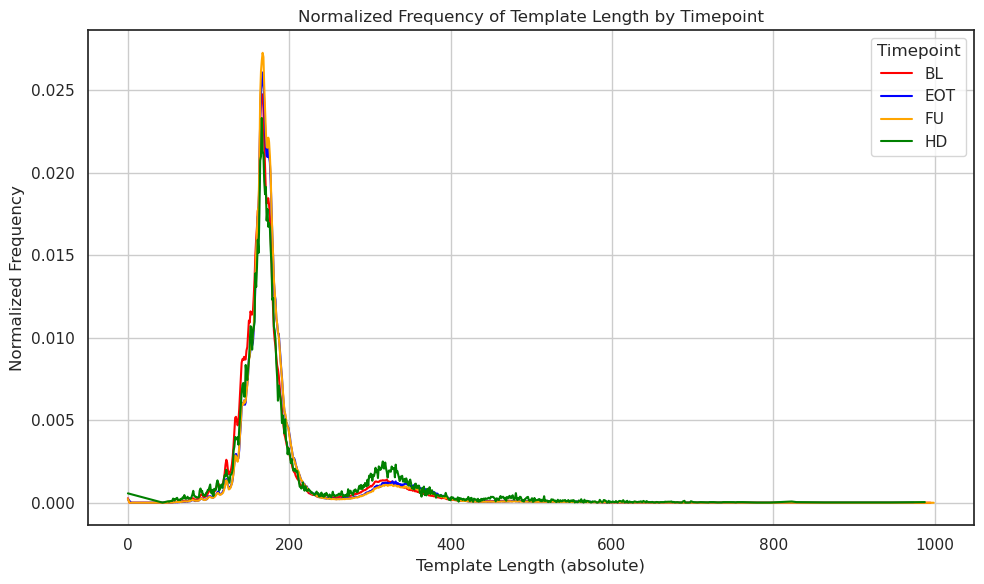

In [139]:
# Combine all file lists
all_files = BL_files_duplex + FU_files_duplex + HD_files_duplex + EOT_files_duplex

# Create an empty list to collect data
all_data = []

# Function to determine timepoint from file name
def get_timepoint(file):
    if "_BL_" in file:
        return "BL"
    elif "_HL_" in file:
        return "HD"
    elif "_2CX_" in file:
        return "FU"
    elif "_EOT_" in file:  # Include EOT timepoint
        return "EOT"
    else:
        return "Unknown"

# Read the files and extract only timepoint and template_length columns
for file in all_files:
    # Load data
    df = pd.read_csv(file, usecols=['template_length'])
    
    # Add a new column 'Timepoint' based on the file name
    df['Timepoint'] = get_timepoint(file)
    
    # Take absolute values of template_length
    df['template_length'] = df['template_length'].abs()
    
    # Append to list
    all_data.append(df)

# Concatenate all the data into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Filter out template lengths greater than 1000
filtered_df = combined_df[combined_df['template_length'] <= 1000]

# Calculate frequency of each template_length per timepoint
frequency_df = filtered_df.groupby(['Timepoint', 'template_length']).size().reset_index(name='Frequency')

# Normalize the frequency per timepoint
frequency_df['Total'] = frequency_df.groupby('Timepoint')['Frequency'].transform('sum')
frequency_df['Normalized_Frequency'] = frequency_df['Frequency'] / frequency_df['Total']

# Define custom color palette for timepoints
custom_palette = {'BL': 'red', 'HD': 'green', 'FU': 'orange', 'EOT': 'blue'}  # Include EOT color

# Plotting the normalized frequency distribution
plt.figure(figsize=(10, 6))

# Use seaborn to plot the normalized frequency distribution, color-coded by 'Timepoint'
sns.lineplot(data=frequency_df, x='template_length', y='Normalized_Frequency', hue='Timepoint', palette=custom_palette)

# Additional plot formatting
plt.title('Normalized Frequency of Template Length by Timepoint')
plt.xlabel('Template Length (absolute)')
plt.ylabel('Normalized Frequency')
plt.grid(True)

plt.tight_layout()

# Show plot
plt.show()

In [140]:
# Define timepoint color mapping
timepoint_dict = {'BL': 'red', 'HD': 'green', 'FU': 'orange', 'EOT': 'blue'}

# Create a dictionary to hold data for each timepoint
timepoint_data = {'BL': [], 'HD': [], 'FU': [], 'EOT': []}  # Include EOT in the dictionary

# Define what constitutes short and long reads (adjust threshold as needed)
short_threshold = 150

# File patterns for duplex files
BL_files_duplex = glob.glob("*_BL_duplex.csv")
FU_files_duplex = glob.glob("*_2CX_duplex.csv")
HD_files_duplex = glob.glob("*_HL_cfDNA_duplex.csv")
EOT_files_duplex = glob.glob("*_EOT_duplex.csv")  # Add EOT file patterns

# Combine all file lists
duplex_files = BL_files_duplex + FU_files_duplex + HD_files_duplex + EOT_files_duplex

# Process each duplex file
for file in duplex_files:
    # Determine the timepoint from the file name
    if "_BL_" in file:
        timepoint = "BL"
    elif "_HL_" in file:
        timepoint = "HD"
    elif "_2CX_" in file:
        timepoint = "FU"
    elif "_EOT_" in file:  # Include EOT timepoint
        timepoint = "EOT"
    else:
        timepoint = "Unknown"
    
    if timepoint != "Unknown":
        # Load the CSV data
        df = pd.read_csv(file)
        
        # Take the absolute value of the template_length column and filter out lengths > 1000
        df["template_length"] = df["template_length"].abs()
        df_filtered = df[df['template_length'] <= 1000]
        
        # Append the template lengths to the respective timepoint list
        timepoint_data[timepoint].extend(df_filtered['template_length'].tolist())

# Calculate statistics for each timepoint
results = {'Statistic': ['Mean', 'Median', 'Short_Reads', 'Long_Reads', 'Fragment_Size_Ratio', 'Number_of_Reads']}
for timepoint, lengths in timepoint_data.items():
    # Convert the lengths list to a Pandas series
    lengths_series = pd.Series(lengths)
    
    # Calculate mean and median
    mean_length = round(lengths_series.mean(), 2)
    median_length = round(lengths_series.median(), 2)
    
    # Count short and long reads
    short_reads = (lengths_series < short_threshold).sum()
    long_reads = (lengths_series >= short_threshold).sum()
    
    # Calculate fragment size ratio (short reads / long reads)
    fragment_size_ratio = round(short_reads / long_reads if long_reads > 0 else 0, 2)
    
    # Store the results in the dictionary
    results[timepoint] = [
        mean_length,  # Display mean with two decimals
        median_length,  # Display median with two decimals
        short_reads,
        long_reads,
        fragment_size_ratio,  # Display ratio with two decimals
        len(lengths)
    ]

# Convert the results to a DataFrame for easy viewing
summary_df = pd.DataFrame(results)

# Display the DataFrame
print(summary_df)

             Statistic           BL          HD           FU         EOT
0                 Mean       187.69      202.78       189.33      192.58
1               Median       168.00      172.00       172.00      172.00
2          Short_Reads   3958652.00   790010.00   2512388.00   509953.00
3           Long_Reads  17468530.00  4093272.00  19414582.00  3887890.00
4  Fragment_Size_Ratio         0.23        0.19         0.13        0.13
5      Number_of_Reads  21427182.00  4883282.00  21926970.00  4397843.00


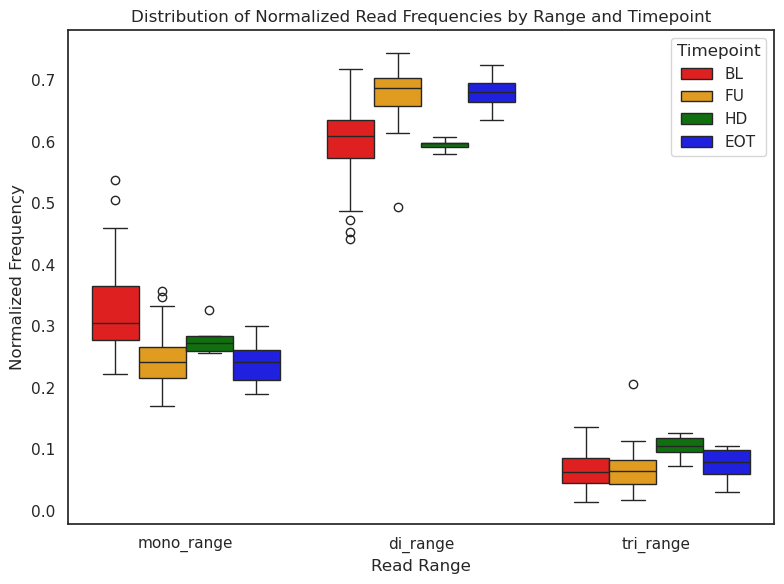

In [141]:
# Initialize an empty DataFrame for counts
counts_df = pd.DataFrame(columns=['file_prefix', 'range', 'read_count', 'Timepoint', 'frequency'])

# Define ranges
ranges = {
    'mono_range': (0, 160),
    'di_range': (161, 320),
    'tri_range': (321, 480)
}

# Assign colors to timepoints (including EOT)
timepoint_colors = {
    'BL': 'red',
    'HD': 'green',
    'FU': 'orange',
    'EOT': 'blue'  # Added EOT timepoint color
}

# File patterns for duplex files
BL_files_duplex = glob.glob("*_BL_duplex.csv")
FU_files_duplex = glob.glob("*_2CX_duplex.csv")
HD_files_duplex = glob.glob("*_HL_cfDNA_duplex.csv")
EOT_files_duplex = glob.glob("*_EOT_duplex.csv")  # Include EOT files

# Combine all file lists
duplex_files = BL_files_duplex + FU_files_duplex + HD_files_duplex + EOT_files_duplex

# Process each duplex file
for file in duplex_files:
    # Determine the timepoint based on the file name
    if "_BL_" in file:
        timepoint = "BL"
    elif "_HL_" in file:
        timepoint = "HD"
    elif "_2CX_" in file:
        timepoint = "FU"
    elif "_EOT_" in file:  # Include EOT timepoint
        timepoint = "EOT"
    else:
        timepoint = "Unknown"
    
    if timepoint != "Unknown":
        # Get the file prefix (first 5 characters of file name)
        file_prefix = os.path.splitext(os.path.basename(file))[0][:5]
        
        # Load the CSV data
        input_df = pd.read_csv(file)
        
        # Take the absolute value of 'template_length'
        input_df['template_length_abs'] = input_df['template_length'].abs()

        # Calculate the total number of reads for this timepoint (absolute template length <= 1000)
        total_reads = input_df[input_df['template_length_abs'] <= 1000].shape[0]
        
        # Loop through each defined range and calculate the read counts and frequencies
        for range_name, (start, end) in ranges.items():
            count = input_df[(input_df['template_length_abs'] >= start) & (input_df['template_length_abs'] <= end)].shape[0]
            frequency = count / total_reads if total_reads > 0 else 0
            counts_df = pd.concat([counts_df, pd.DataFrame({
                'file_prefix': [file_prefix],
                'range': [range_name],
                'read_count': [count],
                'frequency': [frequency],
                'Timepoint': [timepoint]  # Add timepoint to the DataFrame
            })], ignore_index=True)

# Plotting the frequency of read counts
plt.figure(figsize=(8, 6))  # Adjusted figure size

# Create a boxplot with timepoints in different colors
sns.boxplot(x='range', y='frequency', hue='Timepoint', data=counts_df, palette=timepoint_colors)

# Add titles and labels
plt.title('Distribution of Normalized Read Frequencies by Range and Timepoint')
plt.xlabel('Read Range')
plt.ylabel('Normalized Frequency')

# Display the plot
plt.tight_layout()
plt.show()